Imports

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Cargar variables de entorno

In [54]:


DATA_PATH    = Path("../../data/features/hotel_ttoo")
METRICS_DIR = Path("../../models/metrics")
IMPORTANCE_DIR    = METRICS_DIR.parent / "importances"
PRED_DIR= METRICS_DIR.parent / "predictions"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

Cargar datasets

In [55]:
files = {
    "HOTEL_1": DATA_PATH / "HOTEL_1.parquet",
    "HOTEL_2": DATA_PATH / "HOTEL_2.parquet",
    "HOTEL_3": DATA_PATH / "HOTEL_3.parquet",
}

data = {}

for hotel, path in files.items():
    df = pd.read_parquet(path)
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.sort_values("fecha").set_index("fecha")
    df = df.asfreq("D")
    data[hotel] = df

print("✅ Datasets cargados correctamente")

✅ Datasets cargados correctamente


Selección de exógenas correctas

In [56]:
TTOO_MAIN = {
    "HOTEL_1": ["rn_B", "rn_WEL", "rn_J"],
    "HOTEL_2": ["rn_T", "rn_J"],
    "HOTEL_3": ["rn_J", "rn_T"],
}

Definir parámetros Sarima obtenidos anteriormente

In [57]:
SARIMA_PARAMS = {
    "HOTEL_1": ((1, 1, 1), (2, 0, 1, 7)),
    "HOTEL_2": ((2, 1, 3), (2, 0, 1, 7)),
    "HOTEL_3": ((1, 1, 3), (1, 0, 0, 7)),
}

Train Test Split

In [58]:
CUTOFF = pd.Timestamp("2025-01-01")

def train_test_split_cutoff_df(df, cutoff=CUTOFF):
    train = df[df.index < cutoff]
    test  = df[df.index >= cutoff]
    return train, test

Función SARIMAX

In [59]:
def run_sarimax(df, hotel):

    order, seasonal = SARIMA_PARAMS[hotel]

    ttoo_vars = [c for c in TTOO_MAIN[hotel] if c in df.columns]
    cal_vars  = ["is_weekend"]

    cols = ["ocup_total"] + ttoo_vars + cal_vars
    df2  = df[cols].dropna()
    train, test = train_test_split_cutoff_df(df2)

    if len(train) == 0 or len(test) == 0:
        raise ValueError(f"{hotel}: train/test vacío con cutoff {CUTOFF}")

    scaler = StandardScaler()
    X_train_num = pd.DataFrame(
        scaler.fit_transform(train[ttoo_vars]),
        index=train.index, columns=ttoo_vars
    )
    X_test_num = pd.DataFrame(
        scaler.transform(test[ttoo_vars]),
        index=test.index, columns=ttoo_vars
    )

    X_train = pd.concat([X_train_num, train[cal_vars]], axis=1)
    X_test  = pd.concat([X_test_num,  test[cal_vars]],  axis=1)

    model = SARIMAX(
        endog=train["ocup_total"],
        exog=X_train,
        order=order,
        seasonal_order=seasonal,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    res = model.fit(disp=False)

    fc   = res.get_forecast(steps=len(test), exog=X_test)
    pred = fc.predicted_mean
    pred.index = test.index
    ci   = fc.conf_int()

    yt = test["ocup_total"]
    yp = pred

    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / np.maximum(yt, 1e-8))) * 100

    return mae, rmse, mape, res, pred, ci, train, test, X_train.columns.tolist()

Ejecutar modelo

In [60]:
models = {}
rows   = []

for hotel, df in data.items():
    mae, rmse, mape, res, pred, ci, train, test, exog_used = run_sarimax(df, hotel)

    models[hotel] = {
        "res":   res,
        "pred":  pred,
        "ci":    ci,
        "train": train,
        "test":  test,
        "exog":  exog_used,
    }

    rows.append({"hotel": hotel, "MAE": mae, "RMSE": rmse, "MAPE": mape})

results = pd.DataFrame(rows)
display(results)

,hotel,MAE,RMSE,MAPE
0,HOTEL_1,0.088223,0.115243,19.938561
1,HOTEL_2,0.264047,0.294259,45.878928
2,HOTEL_3,0.052725,0.066763,9.552473


Visualización

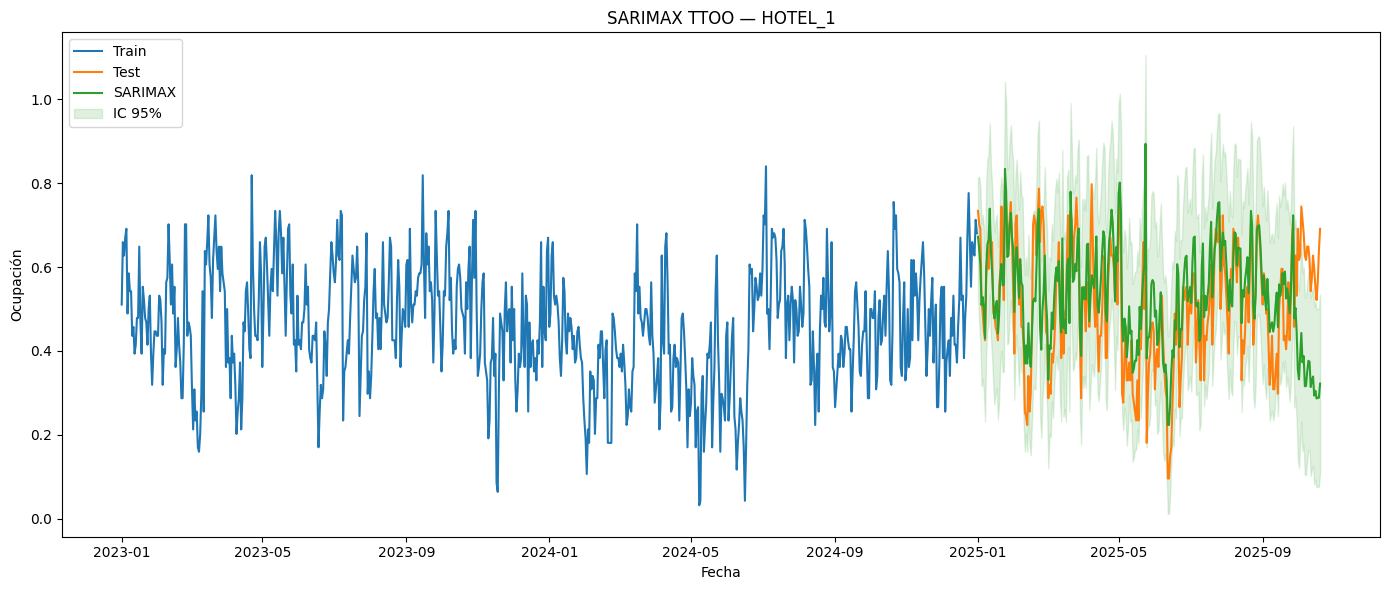

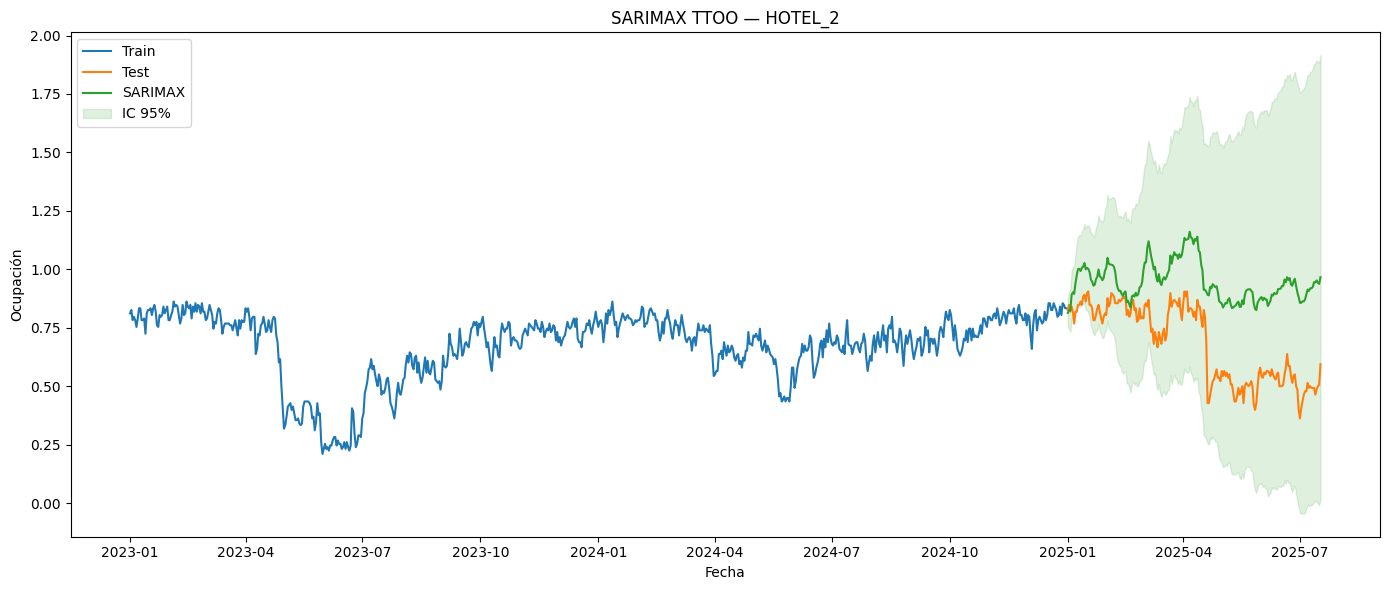

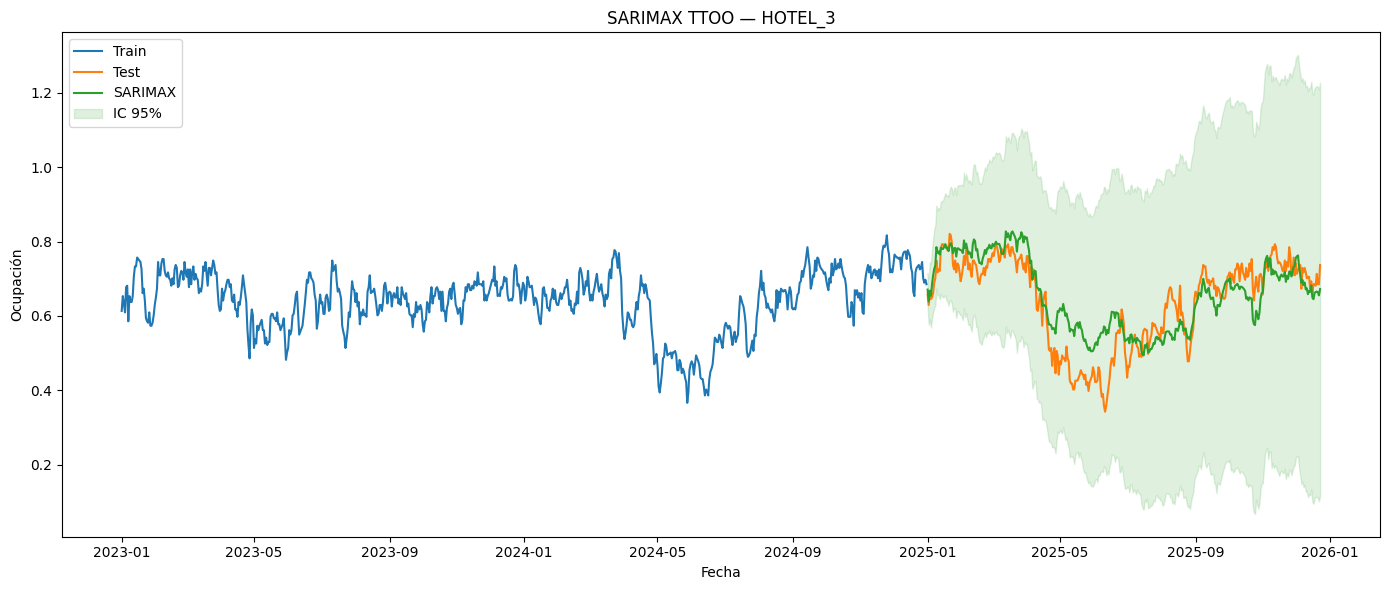

In [61]:
for hotel, obj in models.items():
    train, test, pred, ci = obj["train"], obj["test"], obj["pred"], obj["ci"]

    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train["ocup_total"], label="Train",   color="C0")
    plt.plot(test.index,  test["ocup_total"],  label="Test",    color="C1")
    plt.plot(test.index,  pred,                label="SARIMAX", color="C2")
    plt.fill_between(
        test.index, ci.iloc[:, 0], ci.iloc[:, 1],
        color="C2", alpha=0.15, label="IC 95%"
    )
    plt.title(f"SARIMAX TTOO — {hotel}")
    plt.xlabel("Fecha")
    plt.ylabel("Ocupación")
    plt.legend()
    plt.tight_layout()
    plt.show()

Métricas

In [62]:
results.to_csv(METRICS_DIR / "sarimax_results.csv", index=False)
print("✅ Resultados SARIMAX guardados")

✅ Resultados SARIMAX guardados


Predicciones

In [63]:
pred_rows = []

for hotel, obj in models.items():
    pred = obj["pred"]
    test = obj["test"]["ocup_total"]
    pred = pred.reindex(test.index)

    df_pred = pd.DataFrame({
        "fecha":  test.index,
        "hotel":  hotel,
        "modelo": "SARIMAX",
        "y_real": test.values,
        "y_pred": pred.values,
    })
    pred_rows.append(df_pred)

df_pred_sarimax = pd.concat(pred_rows, ignore_index=True)
df_pred_sarimax.to_parquet(PRED_DIR / "sarimax_predictions.parquet", index=False)
print("✅ Predicciones SARIMAX guardadas")

✅ Predicciones SARIMAX guardadas


Importancia e influencia de exógenas 

In [64]:
def coef_summary(res, exog_cols):
    """
    Devuelve coeficientes + IC + p-values de las variables exógenas SARIMAX,
    ordenado por impacto absoluto.
    """
    params = res.params.reindex(exog_cols)
    conf   = res.conf_int().loc[exog_cols]
    pvals  = res.pvalues.reindex(exog_cols)

    dfc = pd.DataFrame({
        "coef":    params,
        "ci_low":  conf.iloc[:, 0],
        "ci_high": conf.iloc[:, 1],
        "p_value": pvals,
    })

    dfc["signo"]    = np.where(dfc["coef"] > 0, "positivo", "negativo")
    dfc["peso_abs"] = dfc["coef"].abs()

    return dfc.sort_values("peso_abs", ascending=False)

In [65]:
def plot_importance_sarimax(res, hotel, exog_cols, top_k=None):
    """
    Grafica importancias SARIMAX y devuelve el DataFrame para exportación.
    """
    dfc = coef_summary(res, exog_cols)

    if top_k is not None:
        dfc = dfc.head(top_k)

    dfc_sorted = dfc.sort_values("coef")

    plt.figure(figsize=(9, 5 + 0.25 * len(dfc_sorted)))

    colors = dfc_sorted["coef"].apply(lambda v: "#2ca02c" if v > 0 else "#d62728")
    plt.barh(dfc_sorted.index, dfc_sorted["coef"], color=colors)

    for i, (low, high) in enumerate(zip(dfc_sorted["ci_low"], dfc_sorted["ci_high"])):
        plt.plot([low, high], [i, i], color="black", linewidth=1)

    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Impacto en ocupación (coeficiente)")
    plt.title(f"Importancia SARIMAX — {hotel}")
    plt.tight_layout()
    plt.show()

    return dfc


==================== HOTEL_1 ====================


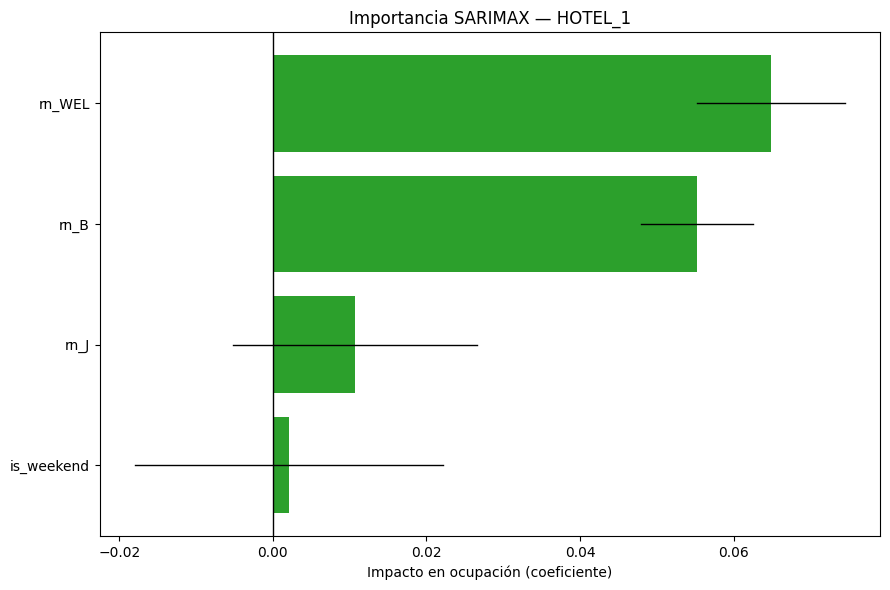


==================== HOTEL_2 ====================


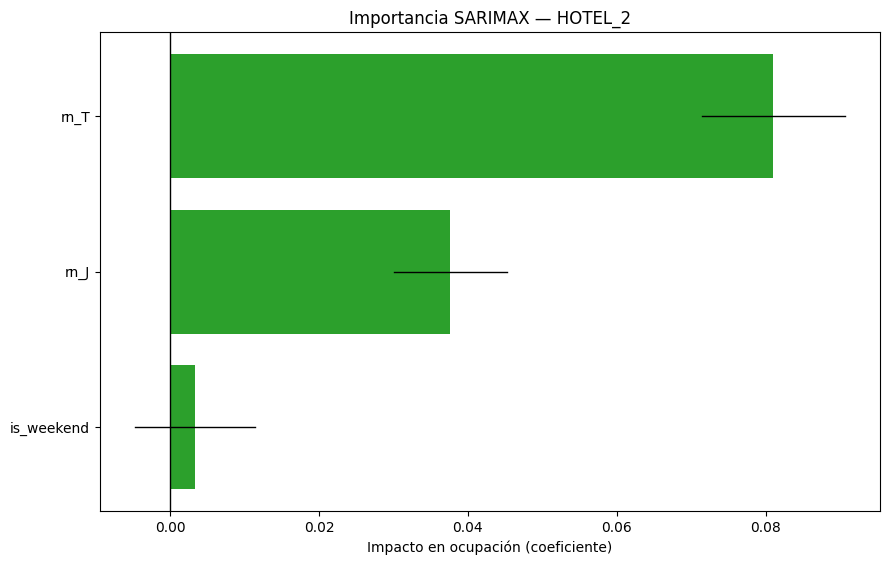


==================== HOTEL_3 ====================


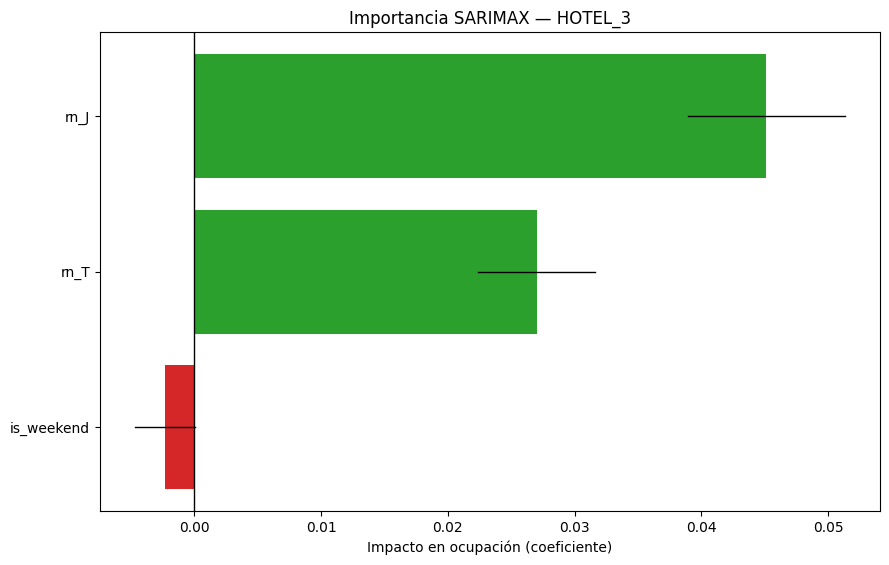


✅ Importancias SARIMAX guardadas en: ..\..\models\importances\sarimax_importance_features.csv


,hotel,feature,coef,ci_low,ci_high,p_value,signo,peso_abs
0,HOTEL_1,rn_WEL,0.064851,0.055254,0.074447,4.824428e-40,positivo,0.064851
1,HOTEL_1,rn_B,0.055242,0.048000,0.062483,1.518827e-50,positivo,0.055242
2,HOTEL_1,rn_J,0.010716,-0.005186,0.026617,1.865753e-01,positivo,0.010716
3,HOTEL_1,is_weekend,0.002142,-0.017898,0.022182,8.340645e-01,positivo,0.002142
4,HOTEL_2,rn_T,0.081024,0.071453,0.090595,7.873534e-62,positivo,0.081024


In [66]:
all_importances = []

for hotel, obj in models.items():
    print(f"\n==================== {hotel} ====================")

    res   = obj["res"]
    exogs = obj["exog"]

    df_imp = plot_importance_sarimax(res, hotel, exogs, top_k=len(exogs))

    df_imp = df_imp.reset_index().rename(columns={"index": "feature"})
    df_imp.insert(0, "hotel", hotel)

    all_importances.append(df_imp)

df_import_final = pd.concat(all_importances, ignore_index=True)

df_import_final.to_csv(IMPORTANCE_DIR / "sarimax_importance_features.csv", index=False)
print("\n✅ Importancias SARIMAX guardadas en:", IMPORTANCE_DIR / "sarimax_importance_features.csv")
df_import_final.head()

Ganancia de SARIMAX vs SARIMA vs ARIMA

In [67]:
arima   = pd.read_csv(METRICS_DIR / "arima_results.csv")[["hotel", "MAE", "RMSE", "MAPE"]]
sarima  = pd.read_csv(METRICS_DIR / "sarima_results.csv")[["hotel", "MAE", "RMSE", "MAPE"]]
sarimax = pd.read_csv(METRICS_DIR / "sarimax_results.csv")[["hotel", "MAE", "RMSE", "MAPE"]]

In [68]:
def build_comp(reference_df, reference_name):
    ref = reference_df.rename(columns={
        "MAE":  f"MAE_{reference_name}",
        "RMSE": f"RMSE_{reference_name}",
        "MAPE": f"MAPE_{reference_name}",
    })
    comp = sarimax.merge(ref, on="hotel", how="left").sort_values("hotel").reset_index(drop=True)
    comp[f"ΔMAE_{reference_name}"]  = comp[f"MAE_{reference_name}"]  - comp["MAE"]
    comp[f"ΔRMSE_{reference_name}"] = comp[f"RMSE_{reference_name}"] - comp["RMSE"]
    comp[f"ΔMAPE_{reference_name}"] = comp[f"MAPE_{reference_name}"] - comp["MAPE"]
    return comp

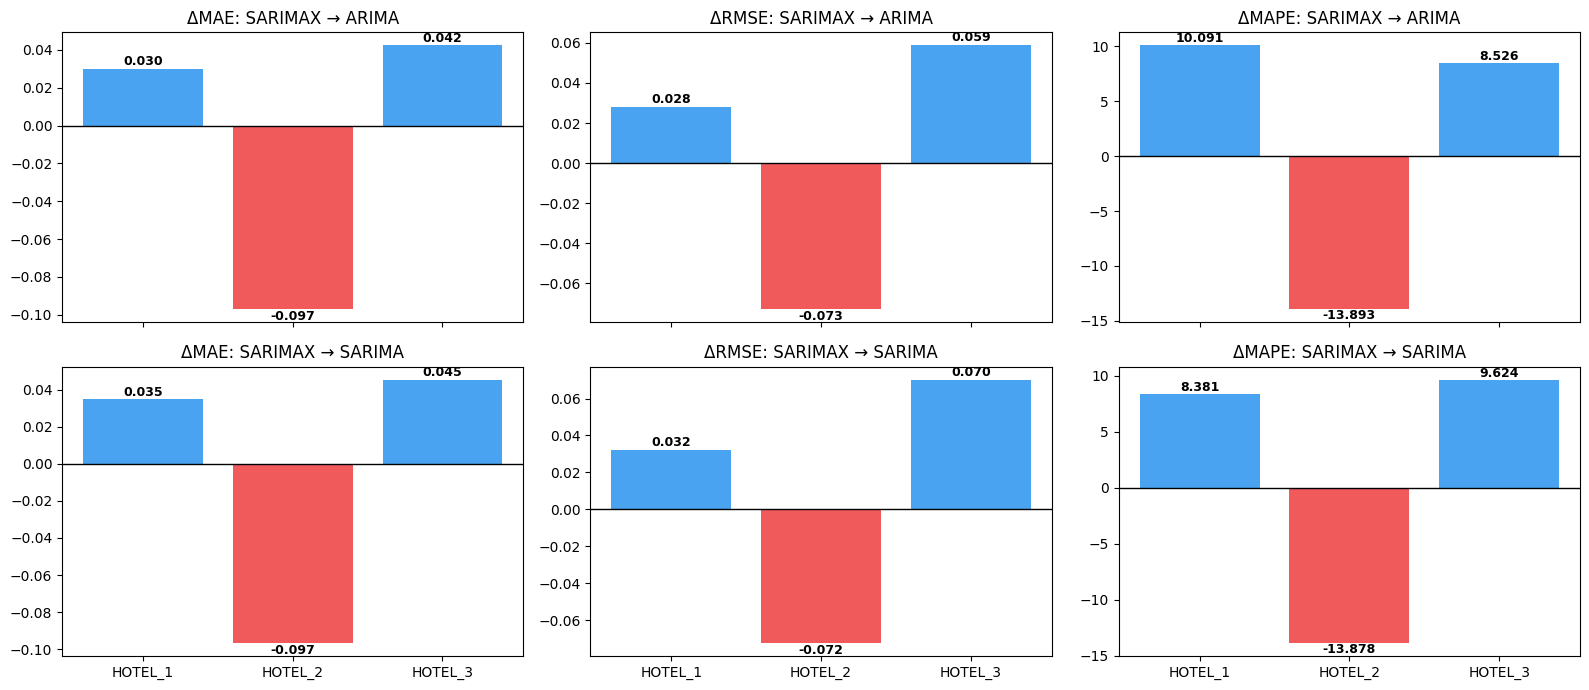

,hotel,MAE_ARIMA,MAE,ΔMAE_ARIMA,RMSE_ARIMA,RMSE,ΔRMSE_ARIMA,MAPE_ARIMA,MAPE,ΔMAPE_ARIMA,MAE_SARIMA,ΔMAE_SARIMA,RMSE_SARIMA,ΔRMSE_SARIMA,MAPE_SARIMA,ΔMAPE_SARIMA
0,HOTEL_1,0.118347,0.088223,0.030123,0.143329,0.115243,0.028086,30.029578,19.938561,10.091018,0.122953,0.034730,0.147184,0.031941,28.319673,8.381113
1,HOTEL_2,0.167308,0.264047,-0.096739,0.221576,0.294259,-0.072683,31.986218,45.878928,-13.892710,0.167298,-0.096749,0.221871,-0.072388,32.001329,-13.877598
2,HOTEL_3,0.095105,0.052725,0.042380,0.125474,0.066763,0.058711,18.078647,9.552473,8.526174,0.097969,0.045244,0.136813,0.070050,19.176906,9.624433


In [69]:
comp_a = build_comp(arima,  "ARIMA")
comp_s = build_comp(sarima, "SARIMA")

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
pairs   = [("ARIMA", 0), ("SARIMA", 1)]
metrics = ["ΔMAE", "ΔRMSE", "ΔMAPE"]

for name, row in pairs:
    comp   = comp_a if name == "ARIMA" else comp_s
    hotels = comp["hotel"].tolist()
    for j, m in enumerate(metrics):
        col    = f"{m}_{name}"
        vals   = comp[col].values
        ax     = axes[row, j]
        colors = [
            "#49a3f1" if (pd.notna(v) and v > 0) else ("#f15a5a" if pd.notna(v) else "#cccccc")
            for v in vals
        ]
        bars = ax.bar(hotels, vals, color=colors)
        ax.axhline(0, color="k", lw=1)
        ax.set_title(f"{m}: SARIMAX → {name}")
        for b, v in zip(bars, vals):
            if pd.isna(v):
                continue
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + (0.0005 if v >= 0 else -0.0005),
                f"{v:.3f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=9, fontweight="bold", color="black",
            )

plt.tight_layout()
plt.show()

cols_keep = [
    "hotel",
    "MAE_ARIMA", "MAE", "ΔMAE_ARIMA",
    "RMSE_ARIMA", "RMSE", "ΔRMSE_ARIMA",
    "MAPE_ARIMA", "MAPE", "ΔMAPE_ARIMA",
    "MAE_SARIMA", "ΔMAE_SARIMA",
    "RMSE_SARIMA", "ΔRMSE_SARIMA",
    "MAPE_SARIMA", "ΔMAPE_SARIMA",
]

tbl = (
    comp_a.merge(
        comp_s[[
            "hotel", "MAE_SARIMA", "RMSE_SARIMA", "MAPE_SARIMA",
            "ΔMAE_SARIMA", "ΔRMSE_SARIMA", "ΔMAPE_SARIMA",
        ]],
        on="hotel", how="left",
    )[cols_keep]
    .sort_values("hotel")
)
display(tbl)

# 📊 Conclusiones — SARIMAX (exógenas contemporáneas + is_weekend)

## 🎯 Objetivo

Evaluar si un modelo SARIMAX, utilizando únicamente **variables causales contemporáneas**, es decir:

- volúmenes reales diarios por turoperador (`rn_*`)  
- calendario mínimo (`is_weekend`)  

puede mejorar la predicción de la ocupación diaria frente a modelos puramente temporales (ARIMA y SARIMA), y analizar la influencia real de cada exógena mediante coeficientes e intervalos de confianza.

---

# ✅ 1. Metodología y problemas encontrados

El desarrollo de SARIMAX requirió un ajuste profundo del pipeline debido a varios problemas detectados:

### ❌ Overfitting por exceso de exógenas  
Cuando se incluían **todos los TTOO** a la vez, el modelo mostraba comportamientos de memorización del conjunto de test, dando lugar a métricas artificialmente buenas y no representativas de capacidad predictiva real.

### ❌ Fuga de información por variables no causales  
Variables como:
- `dayofyear`
- `weekofyear`
- dummies estacionales (`season_*`)
- indicadores futuros (`post_*`)

introducían patrones artificiales y fuga indirecta de información temporal.

### ❌ Colinealidad extrema  
Muchos turoperadores presentan alta correlación entre sí, lo que genera inestabilidad en los coeficientes de un modelo lineal como SARIMAX.

### ❌ Variables categóricas ordinales  
El uso de variables como `dow` (0–6) inducía un orden artificial y explicaba en exceso la ocupación, falseando tanto coeficientes como interpretaciones posteriores.

---

## ✅ Solución profesional aplicada

El SARIMAX final se reconstruyó para que fuera:

- **causal**
- **sin fuga de información**
- **estable**
- **sin dummies artificiales**
- **robusto frente a colinealidad**

El modelo definitivo utiliza:

- **2–3 TTOO relevantes por hotel** (selección a priori)
- **solo `is_weekend`** como variable de calendario
- **exógenas contemporáneas**
- **estandarización de variables numéricas**
- **enforce_stationarity=True**
- **enforce_invertibility=True**

Además, se adopta un **criterio temporal homogéneo**:

- **Entrenamiento:** fechas < 2025‑01‑01  
- **Test:** fechas ≥ 2025‑01‑01 hasta el último histórico disponible  

Este esquema alinea SARIMAX con el resto de modelos del proyecto y elimina sesgos temporales en la comparación.

---

# ✅ 2. Resultados finales en test (cutoff fijo)

| Hotel | MAE | RMSE | MAPE |
|-------|---------|---------|---------|
| **HOTEL_1** | 0.0882 | 0.1152 | 19.94% |
| **HOTEL_2** | 0.2640 | 0.2943 | 45.88% |
| **HOTEL_3** | 0.0527 | 0.0668 | 9.55% |

### ✅ Interpretación

- **HOTEL_3** es el hotel mejor explicado por SARIMAX, con errores muy bajos en todas las métricas.
- **HOTEL_1** mejora de forma clara respecto a modelos puramente temporales, aunque mantiene ruido operativo propio de un hotel urbano.
- **HOTEL_2** empeora notablemente, reflejando una serie extremadamente estable donde la incorporación de exógenas contemporáneas no aporta capacidad predictiva adicional.

---

# ✅ 3. Importancia de exógenas (coeficientes + IC95%)

## 🏨 HOTEL_1 — Urbano (dominancia OTA)

- `rn_WEL` → **+0.0649**, muy significativo  
- `rn_B` → **+0.0552**, muy significativo  
- `rn_J` → no significativo  
- `is_weekend` → no significativo  

**Interpretación:**  
La ocupación de HOTEL_1 está impulsada principalmente por **canales OTA online**. El fin de semana no introduce una variación estadísticamente relevante.

---

## 🏨 HOTEL_2 — Vacacional hiperestable

- `rn_T` → **+0.0810**, dominante  
- `rn_J` → **+0.0377**, significativo  
- `is_weekend` → no significativo  

**Interpretación:**  
HOTEL_2 depende casi exclusivamente del flujo turoperado. La ocupación es tan estable que incluso un modelo causal no mejora la predicción.

---

## 🏨 HOTEL_3 — Vacacional turoperado

- `rn_J` → **+0.0451**, driver principal  
- `rn_T` → **+0.0270**, complementario  
- `is_weekend` → efecto negativo leve, débilmente significativo  

**Interpretación:**  
HOTEL_3 presenta una estructura causal clara dominada por el turoperador J, con capacidad predictiva elevada cuando se incorporan exógenas relevantes.

---

# ✅ 4. Comparativa con ARIMA y SARIMA

Comparando SARIMAX con modelos puramente temporales bajo el mismo periodo de test:

- **HOTEL_1:** mejora consistente frente a ARIMA y SARIMA.  
- **HOTEL_2:** empeora claramente; la serie es demasiado persistente y estable.  
- **HOTEL_3:** mejora muy significativa en todas las métricas.

👉 SARIMAX **añade valor cuando la ocupación está realmente gobernada por flujos operativos de negocio**.

---

# ✅ 5. Conclusión general (versión final)

El SARIMAX final, una vez depurado para evitar fuga, colinealidad y sobreajuste, es un modelo:

- ✅ **Causal y metodológicamente correcto**
- ✅ **Interpretativo**, con coeficientes y signos coherentes
- ✅ **Realista**, sin memorización artificial
- ✅ **Útil para negocio**, al identificar drivers reales de ocupación

Sin embargo, su rendimiento depende fuertemente del **tipo de hotel**:

- Funciona muy bien en hoteles **turoperados** con drivers claros (HOTEL_3).
- Mejora resultados en hoteles urbanos con mix dinámico (HOTEL_1).
- Aporta poco o incluso empeora en **series extremadamente estables** (HOTEL_2).

Estas limitaciones justifican el avance hacia **modelos de Machine Learning (Random Forest y XGBoost)**, capaces de capturar **no linealidades**, **interacciones complejas** y **choques de demanda**, manteniendo a SARIMAX como un **punto de referencia causal e interpretativo** dentro del proyecto.